In [22]:
#Import modules
import sys
import os
sys.path.append('../')
sys.path.append('../modules')
from Class_sem2dpack import *
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from mpl_toolkits.mplot3d import Axes3D

#Load data
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/ISS_Grid_Test"
is_overburden = False
fmin, fmax = 0.01, 50.0
SEM = sem2dpack(direct1)


Reading grid information...
Reading header file...
0.001 5001 90
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, n

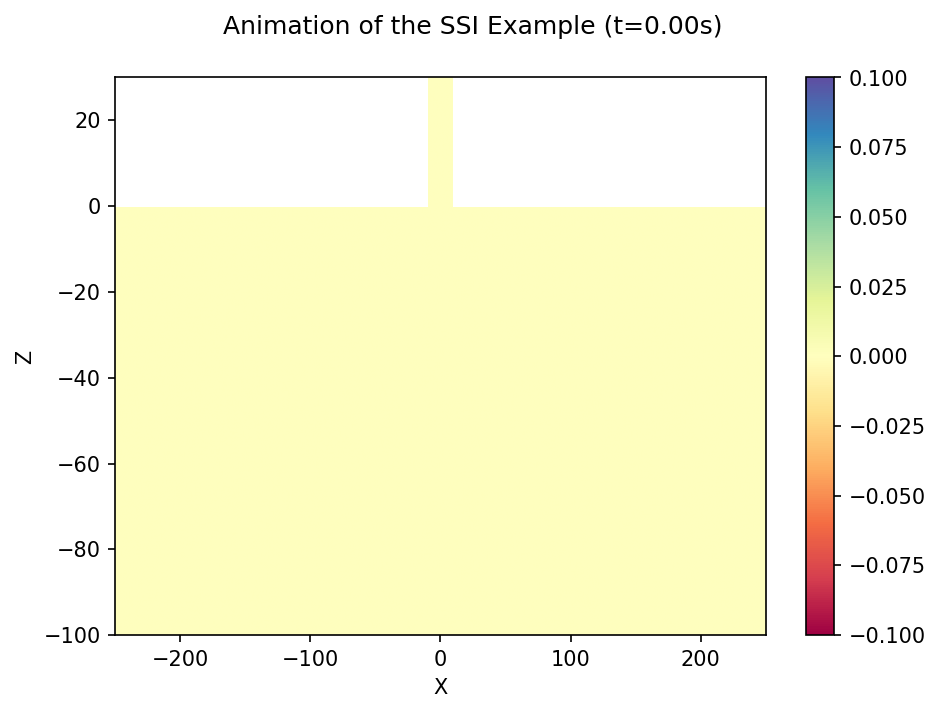

In [23]:
SEM.read_seismo('x')
Vx = SEM.velocity[:,:]

#Create axis
fig = plt.figure()
ax_2d = fig.add_subplot(1,1,1)
#ax_3d = fig.add_subplot(1,1,1,projection='3d')
#cax = ax_3d.inset_axes([0.3, 0.07, 0.4, 0.04])
cbar_2d = plt.colorbar(plt.imshow(np.zeros([2,2])), ax=ax_2d)
#cbar_3d = plt.colorbar(plt.imshow(np.zeros([2,2])), cax=cax)

#Create Colormap and Norm
cmap = plt.cm.Spectral
v_min, v_max = -0.01, 0.01
norm = plt.Normalize(v_min,v_max)

#Get coordinates of the mesh and creation of meshgrid
X_Coord, Z_Coord = SEM.mdict["coord"][:,0] , SEM.mdict["coord"][:,1]
#X_Coord, Z_Coord = SEM.rcoord[:,0], SEM.rcoord[:,1]
x_min, x_max = X_Coord.min(), X_Coord.max()
z_min, z_max = Z_Coord.min(), Z_Coord.max()
N_samp = 1000
X = np.linspace(x_min, x_max, N_samp)
Z = np.linspace(z_min, z_max, N_samp)
X,Z = np.meshgrid(X,Z)

#Reading and processing of the data
def create_path(comp,t):
    n = f"{t:03d}"
    path = SEM.directory + f'v{comp}_{n}_sem2d.dat'
    return path

def read_snapshot_data(path):
    field = SEM.readField(path)
    fieldgrid = griddata((X_Coord,Z_Coord), field, (X,Z), method='linear')
    mask = (Z > 0) & (abs(X) > 10)
    fieldgrid[mask] = None
    return fieldgrid

def read_stations_data(t):
    field = Vx[t,:]
    #field = np.reshape(field,[-1,5])
    fieldgrid = griddata((X_Coord,Z_Coord), field, (X,Z), method='linear')
    mask = (Z > 0) & (abs(X) > 10)
    fieldgrid[mask] = None
    return fieldgrid

#Plot data
def plot_field(fieldgrid, norm):
    im = ax_2d.imshow(fieldgrid,origin='lower',extent=[x_min, x_max, z_min, z_max], aspect='auto', cmap=plt.cm.Spectral,norm=norm)
    cbar_2d.update_normal(im)

def plot_3dfield(fieldgrid):
    norm = plt.Normalize(vmin=v_min,vmax=v_max)
    color = plt.get_cmap('Spectral')(norm(fieldgrid))
    im = ax_3d.plot_surface(X,fieldgrid,Z, facecolors=color)
    cbar_3d.update_normal(im)


def animate_2d(t):
    plt.cla()
    norm = plt.Normalize(-0.1, 0.1)
    path = create_path('x',t)
    fieldgrid = read_snapshot_data(path)
    fig.suptitle("Animation of the SSI Example (t={:.2f}s)".format(t/100))
    if t>15:
        norm=plt.Normalize(-0.001,0.001)
    plot_field(fieldgrid, norm)
    ax_2d.set_xlabel('X')
    ax_2d.set_ylabel('Z')
    ax_2d.set_xlim(-250,250)
    ax_2d.set_ylim(-100,30)
    fig.tight_layout()

def animate_3d(t):
    plt.cla()
    #path = create_path('x',t)
    #fieldgrid = read_snapshot_data(path)
    fieldgrid = read_stations_data(t)
    fig.suptitle("Animation of the Prenolin Example with Volvi Solid Model (t={:.2f}s)".format(t*20*1e-5))
    plot_3dfield(fieldgrid)
    ax_3d.set_xlabel('X')
    ax_3d.set_ylabel('Vx')
    ax_3d.set_zlabel('Z')
    ax_3d.set_ylim(v_min,v_max)
    ax_3d.view_init(elev=20, azim=30)
    fig.tight_layout()

    
plt.rcParams['figure.dpi'] = 150
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128



writervideo = anim.PillowWriter(fps=5)
#anim.FuncAnimation(fig, animate_2d, np.arange(0,50, 1))
animation=anim.FuncAnimation(fig, animate_2d, np.arange(0,50, 1))
animation.save(os.getcwd()+'/SSI_Grid.gif', writer=writervideo) 

